LoRA - is a low-ranking adaptation - a tool for training large models (diffusion in this case) on custom data changing only several components in deep layers - in this case, in U-Net, which is a basic lavel if diffusion model, same as VAE and text-tokenizer. LoRA is applying to self-attention mechanism inside U-Net and is addind a small weight matrices to K, Q, V and Out layers of self-attention, which could be trained separatly from all model. Thats why it is possible to train a large with custom data on low calculation resources.

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt

import torch 
from torch.optim import AdamW
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image 
from tqdm import tqdm 
from torchinfo import summary 

In [29]:
!pip install torchinfo 

In [2]:
# pip install -U peft

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
device

'cpu'

In [5]:
base_dir = "/kaggle/input/flickr8k"
images_dir = os.path.join(base_dir, "images")
captions_path = os.path.join(base_dir, "captions.txt")


output_dir = "/kaggle/working/flickr_lora_dataset"
os.makedirs(output_dir, exist_ok=True)

In [6]:
data = pd.read_csv(captions_path, sep=',', names=['file', 'caption'])

In [7]:
data

,file,caption
0,image,caption
1,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
2,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
3,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
4,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
...,...,...
40451,997722733_0cb5439472.jpg,A man in a pink shirt climbs a rock face
40452,997722733_0cb5439472.jpg,A man is rock climbing high in the air .
40453,997722733_0cb5439472.jpg,A person in a red shirt climbing up a rock fac...
40454,997722733_0cb5439472.jpg,A rock climber in a red shirt .


In [8]:
data = data.drop(0)
data

,file,caption
1,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
2,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
3,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
4,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
5,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
...,...,...
40451,997722733_0cb5439472.jpg,A man in a pink shirt climbs a rock face
40452,997722733_0cb5439472.jpg,A man is rock climbing high in the air .
40453,997722733_0cb5439472.jpg,A person in a red shirt climbing up a rock fac...
40454,997722733_0cb5439472.jpg,A rock climber in a red shirt .


In [9]:
data[data["file"] == "1000268201_693b08cb0e.jpg"]["caption"]

1    A child in a pink dress is climbing up a set o...
2                A girl going into a wooden building .
3     A little girl climbing into a wooden playhouse .
4    A little girl climbing the stairs to her playh...
5    A little girl in a pink dress going into a woo...
Name: caption, dtype: object

In [10]:
# this will put data into a dictionary, where file name will be for a key and it'll have a list of captions as a value
grouped = data.groupby("file")["caption"].apply(list).to_dict()

In [11]:
root = "/kaggle/input/flickr8k/Images"           
output_dir = "/kaggle/working/flickr_lora_dataset"  
os.makedirs(output_dir, exist_ok=True)

for img_name, captions in grouped.items():
    # this will put each list of captions into a sinlge row
    text = " ".join(captions)

    # this will create a separate .txt file for each cpation
    txt_path = os.path.join(output_dir, img_name.replace(".jpg", ".txt"))

    # and this will write down caption rows into a single .txt file
    with open(txt_path, "w") as f:
        f.write(text)

    # this is for images replacing into working directory 
    src_img = os.path.join(root, img_name)
    dst_img = os.path.join(output_dir, img_name)
    if os.path.exists(src_img):
        os.system(f"cp '{src_img}' '{dst_img}'")


In [13]:
link = "/kaggle/working/flickr_lora_dataset"
lst = os.listdir(link)
path = os.path.join(link, lst[8])

with open(path, "r") as f:
    for i in f:
        print(i)

A black and white dog jumps over a pole while splashing water around . A wet dog is jumping over a hurdle . a wet dog jumps over a bar . A wet spaniel clears a jump . A wet , white dog is jumping over obstacles .


In [14]:
# taking pre-trained tokenizer from original model 

from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
tokenizer = pipe.tokenizer

2025-10-14 15:11:10.410836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760454670.671550      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760454670.748720      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [16]:
transformer = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  
])

In [17]:
class CustomDataset(Dataset):
    def __init__(self, data_link, tokenizer, transformer=None, max_length = 77):
        self.data_link = data_link
        self.data_list = os.listdir(self.data_link)
        self.tokenizer = tokenizer
        self.transformer = transformer
        self.max_length = max_length
        
        self.images = []
        for obj in self.data_list:
            if obj.endswith(".jpg"):
                self.images.append(obj)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_link, self.images[idx])
        txt_path = img_path.replace(".jpg", ".txt")

        image = Image.open(img_path).convert("RGB")
        if self.transformer:
            image = self.transformer(image)

        with open(txt_path, "r") as f:
            caption = f.read().strip()

        tokens = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "pixel_values": image,
            "input_ids": tokens.input_ids.squeeze(0),
            "attention_mask": tokens.attention_mask.squeeze(0),
            "text": caption
        }

In [18]:
link = "/kaggle/working/flickr_lora_dataset"
dataset = CustomDataset(link, tokenizer, transformer)

In [19]:
dataset, _ = random_split(dataset, [0.5, 0.5])

In [20]:
len(dataset)

4046

In [21]:
def output(limit, data):

    for i, obj in enumerate(data):
        img = obj["pixel_values"]
        img = img.permute(1, 2, 0)
        img = (img + 1) / 2
    
        text = f'{obj["text"][:20]}..'
    
        plt.imshow(img)
        plt.title(text)
    
        plt.axis("off")
    
        plt.show()
    
        if i+1 == limit:
            break
    

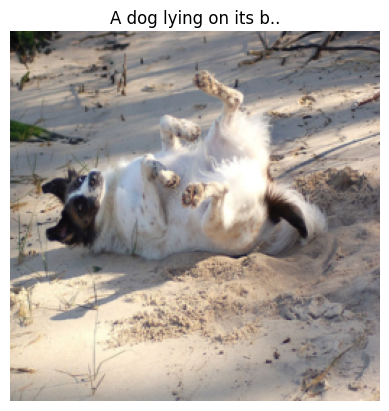

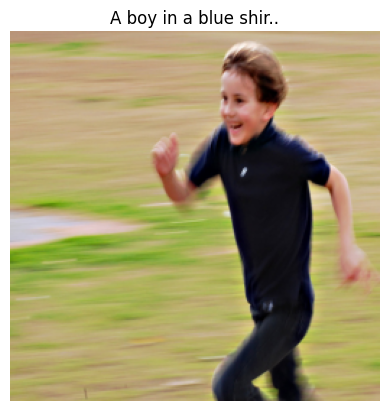

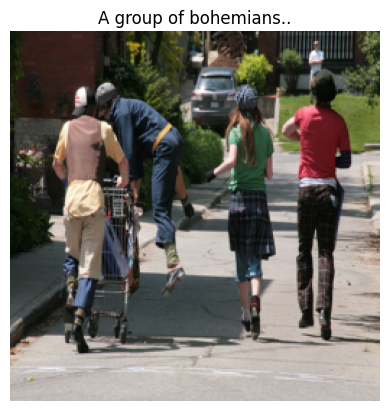

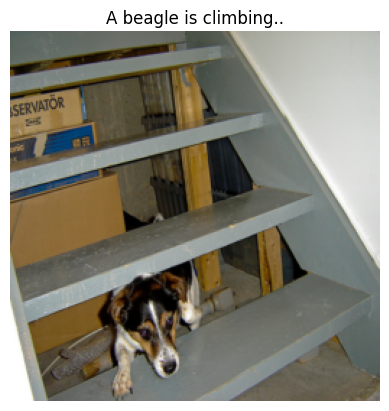

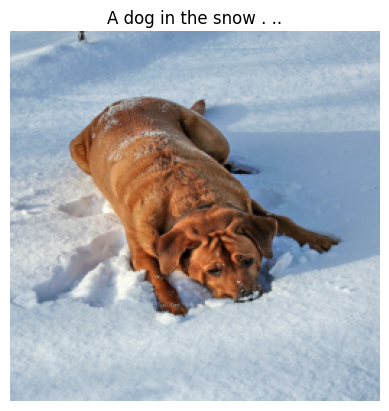

In [22]:
output(5, dataset)

In [23]:
x = dataset[0]
x['pixel_values'].shape

torch.Size([3, 256, 256])

In [24]:
# use small batch-size
batch_size = 4
dl = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [25]:
from peft import LoraConfig, get_peft_model, PeftModel

# load pre-trained model (one more time)

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device != "cpu" else torch.float32
).to(device)

# add a configuration for LoRA

lora_config = LoraConfig(
    r=8,                
    lora_alpha=16,      
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],  # attention-блоки
    lora_dropout=0.1,
    bias="none"
)

# upload LoRA configuration into U-net part of diffusion model
pipe.unet = get_peft_model(pipe.unet, lora_config)
print("Done!")



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Done!


In [26]:
print(pipe.unet.peft_config)

{'default': LoraConfig(task_type=None, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules={'to_out.0', 'to_q', 'to_k', 'to_v'}, exclude_modules=None, lora_alpha=16, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False)}


In [27]:
# load components of diffusion model 

unet = pipe.unet
vae = pipe.vae
text_encoder = pipe.text_encoder
scheduler = pipe.scheduler

In [33]:
x = torch.randn(1, 4, 64, 64)  
timestep = torch.tensor([0])
encoder_hidden_states = torch.randn(1, 77, 768)  # 77 токенов по 768 признаков, как у CLIP

summary(
    unet,
    input_data=(x, timestep, encoder_hidden_states)
)


Layer (type:depth-idx)                                                           Output Shape              Param #
PeftModel                                                                        [1, 4, 64, 64]            --
├─LoraModel: 1-1                                                                 --                        --
│    └─UNet2DConditionModel: 2-1                                                 [1, 4, 64, 64]            --
│    │    └─Timesteps: 3-1                                                       [1, 320]                  --
│    │    └─TimestepEmbedding: 3-2                                               [1, 1280]                 (2,050,560)
│    │    └─Conv2d: 3-3                                                          [1, 320, 64, 64]          (11,840)
│    │    └─ModuleList: 3-4                                                      --                        250,187,968
│    │    └─UNetMidBlock2DCrossAttn: 3-5                                         [1, 1280, 

In [34]:
type(unet)

peft.peft_model.PeftModel

In [27]:
# freeze all parameters in U-net exept for ones, which containe

for param in unet.parameters():
    param.requires_grad_(False)

for name, param in unet.named_parameters():
    if "lora" in name:
        param.requires_grad_(True)

In [29]:
def train(dl, unet, text_encoder, vae, scheduler, optimizer, loss_fn, epochs, device):
    history = {
        "losses": []
    }

    # use scaler for training 
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        unet.train()
        total_loss = 0.0
        

        for batch in tqdm(dl):
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            optimizer.zero_grad()

            # zero gradients for text_encoder and VAE parts of diffusion model 
            with torch.no_grad():
                text_embeddings = text_encoder(input_ids, attention_mask=attention_mask)[0]
                
            with torch.no_grad():
                latents = vae.encode((pixel_values.to(dtype=torch.float16) * 2 - 1)).latent_dist.sample() * 0.18215
            
            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (1,), device=device).long()
            noisy_latents = scheduler.add_noise(latents, noise, timesteps)

            with torch.cuda.amp.autocast():
                noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embeddings).sample
                loss = loss_fn(noise_pred.float(), noise.float())
    
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        avg_loss = total_loss / len(dl)
        history["losses"].append(avg_loss)
        print(f"[LoRA] | Epoch: {epoch+1} | Loss: {avg_loss:.4f}")
    
    return history        

In [30]:
# 2-5 epochs is usually enough 
epochs = 2
optimizer = AdamW(
    (p for p in unet.parameters() if p.requires_grad),
    lr=1e-4
)

loss_fn = F.mse_loss
history = train(dl, unet, text_encoder, vae, scheduler, optimizer, loss_fn, epochs, device)

/tmp/ipykernel_37/267778519.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/1012 [00:00<?, ?it/s]/tmp/ipykernel_37/267778519.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 1012/1012 [08:27<00:00,  1.99it/s]


[LoRA] | Epoch: 1 | Loss: 0.1813


100%|██████████| 1012/1012 [08:26<00:00,  2.00it/s]

[LoRA] | Epoch: 2 | Loss: 0.1860


In [31]:
# save trained weights -> it will create a "lora_trained" with three (sometimes two) files - .json, .safetensors and .readme -> use first two files in following operation 
unet.save_pretrained("lora_trained")

In [46]:
from diffusers import StableDiffusionPipeline
from peft import PeftModel


# here we load model one more time
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device != "cpu" else torch.float32
).to(device)

# here we load pretrained weights and .json file with configurations 
pipe.unet = PeftModel.from_pretrained(pipe.unet, "lora_trained")

prompt = "A person in a military uniform"
image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
image.save("image.png")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

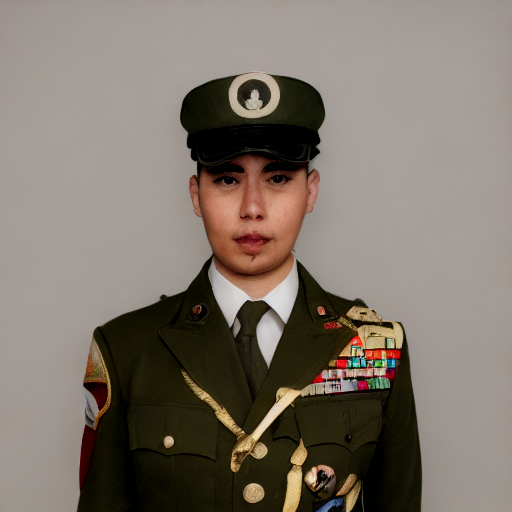

In [47]:
from PIL import Image 
import cv2

link = "/kaggle/working/image.png"
img = Image.open(link)
img